## **2. Exploring Data Analysis (EDA)** <a name="eda"></a>

In [299]:
import pandas as pd
import numpy as np
import json 
file_path = "manga.json"

### **a. Overall Data View** <a name="overall"></a>

In [300]:
df = pd.read_json(file_path)

In [301]:
df.head()

,mal_id,url,images,approved,titles,title,title_english,title_japanese,title_synonyms,type,...,members,favorites,synopsis,background,authors,serializations,genres,explicit_genres,themes,demographics
0,142469,https://myanimelist.net/manga/142469/Daija_ni_Totsuida_Musume,"{'jpg': {'image_url': 'https://cdn.myanimelist.net/images/manga/2/253410.jpg', 'small_image_url': 'https://cdn.myanimelist.net/images/manga/2/253410t.jpg', 'large_image_url': 'https://cdn.myanimelist.net/images/manga/2/253410l.jpg'}, 'webp': {'image_url': 'https://cdn.myanimelist.net/images/manga/2/253410.webp', 'small_image_url': 'https://cdn.myanimelist.net/images/manga/2/253410t.webp', 'large_image_url': 'https://cdn.myanimelist.net/images/manga/2/253410l.webp'}}",True,"[{'type': 'Default', 'title': 'Daija ni Totsuida Musume'}, {'type': 'Synonym', 'title': 'The Girl Who Married the Big Snake'}, {'type': 'Japanese', 'title': '大蛇に嫁いだ娘'}, {'type': 'English', 'title': 'The Great Snake's Bride'}]",Daija ni Totsuida Musume,The Great Snake's Bride,大蛇に嫁いだ娘,[The Girl Who Married the Big Snake],Manga,...,2335,15,"For five hundred years, a giant snake god has lived in the ancient mountain. Miyo, an unlucky woman from the nearby village, is offered as tribute to the great snake. Miyo fears that she will be devoured, but the snake treats her like a wife rather than a meal. His flicking tongue vibrates through gentle words, as his powerful slithering body wraps around hers in an embrace. What does it truly mean to be the bride of a beast?\n\n(Source: Seven Seas Entertainment)","Daija ni Totsuida Musume is as a web manga released on the author's Twitter account. Official serialization began in Comic Marche on February 12, 2021. The series has been published in English as The Great Snake's Bride by Seven Seas Entertainment since July 18, 2023.","[{'mal_id': 56083, 'type': 'people', 'name': 'Fushiashikumo', 'url': 'https://myanimelist.net/people/56083/Fushiashikumo'}]","[{'mal_id': 1643, 'type': 'manga', 'name': 'Comic Marche', 'url': 'https://myanimelist.net/manga/magazine/1643/Comic_Marche'}]","[{'mal_id': 22, 'type': 'manga', 'name': 'Romance', 'url': 'https://myanimelist.net/manga/genre/22/Romance'}, {'mal_id': 37, 'type': 'manga', 'name': 'Supernatural', 'url': 'https://myanimelist.net/manga/genre/37/Supernatural'}]",[],[],[]
1,142471,https://myanimelist.net/manga/142471/Majo_no_Yu,"{'jpg': {'image_url': 'https://cdn.myanimelist.net/images/manga/3/253367.jpg', 'small_image_url': 'https://cdn.myanimelist.net/images/manga/3/253367t.jpg', 'large_image_url': 'https://cdn.myanimelist.net/images/manga/3/253367l.jpg'}, 'webp': {'image_url': 'https://cdn.myanimelist.net/images/manga/3/253367.webp', 'small_image_url': 'https://cdn.myanimelist.net/images/manga/3/253367t.webp', 'large_image_url': 'https://cdn.myanimelist.net/images/manga/3/253367l.webp'}}",True,"[{'type': 'Default', 'title': 'Majo no Yu'}, {'type': 'Japanese', 'title': '魔女ノ湯'}, {'type': 'English', 'title': 'Witch's Hot Spring'}]",Majo no Yu,Witch's Hot Spring,魔女ノ湯,[],Manga,...,107,0,"Sawa, a salaryman working for a black company, wanders into an inn whose motto is ""healing."" The uncared-for but superb bathhouse girls gently and sometimes violently wrap up his tired body... In a mysterious space that appears only at the time of death, the best service is offered... Mystery Eros!\n\n(Source: Shounen Gahousha, translated)",,"[{'mal_id': 12134, 'type': 'people', 'name': 'Hori, Hiroaki', 'url': 'https://myanimelist.net/people/12134/Hiroaki_Hori'}]","[{'mal_id': 451, 'type': 'manga', 'name': 'Young Comic', 'url': 'https://myanimelist.net/manga/magazine/451/Young_Comic'}]","[{'mal_id': 7, 'type': 'manga', 'name': 'Mystery', 'url': 'https://myanimelist.net/manga/genre/7/Mystery'}, {'mal_id': 49, 'type': 'manga', 'name': 'Erotica', 'url': 'https://myanimelist.net/manga/genre/49/Erotica'}]",[],[],"[{'mal_id': 41, 'type': 'manga', 'name': 'Seinen', 'url': 'https://myanimelist.net/manga/genre/41/Seinen'}]"
2,142472,https://m

In [302]:
rows, cols = df.shape
print(f'Number of rows: {rows}')
print(f'Number of cols: {cols}')

Number of rows: 80657
Number of cols: 30


### **b. Column Detail** <a name="column"></a>

In [303]:
descriptions = pd.read_csv('desc.csv')

pd.set_option('display.max_colwidth', None)
descriptions

,Feature,Dtype,Meaning and Role in Project
0,mal_id,int64,The unique identification code for the manga on MyAnimeList. Used as the Primary Key and reference point.
1,url,object,The URL to the MAL page.
2,score,float64,The average score given to the manga. The Target Variable for Regression models (predicting score) and Classification models (predicting High-Score/Low-Score).
3,scored,float64,The scored value (often the same as score).
4,scored_by,float64,The number of users who rated the manga. Used to assess the credibility of the score.
5,rank,float64,The manga's ranking based on its score. Supplementary feature or an alternative target variable.
6,popularity,int64,The popularity rank (based on members). Feature for regression modeling.
7,members,int64,The total number of users who have added the title to their list. Popularity indicator. A crucial feature for the model.
8,favorites,int64,The number of users who have marked the title as a favorite. Indicator of Subjective Quality or engagement.
9,synopsis,object,The plot summary of the manga. Core feature for Content-Based Filtering (requires TF-IDF or Embedding Vectorization).


### **C. Distribution Value** <a name="distribution"></a>

**Data Cleaning**

In [304]:
# Calculate missing values count and ratio
missing_values = df.isnull().sum()
missing_ratio = (missing_values / len(df)) * 100

# Filter out columns with zero missing values
missing_table = pd.DataFrame({
    'Column': missing_values[missing_values > 0].index,
    'Missing Count': missing_values[missing_values > 0].values,
    'Missing Ratio (%)': missing_ratio[missing_values > 0].values
}).sort_values(by='Missing Count', ascending=False)

# Print the table
print(missing_table)

           Column  Missing Count  Missing Ratio (%)
0   title_english          53555          66.398453
5          scored          51395          63.720446
6       scored_by          51395          63.720446
4           score          51395          63.720446
7            rank          24820          30.772283
3         volumes          24242          30.055668
9      background          23882          29.609333
8        synopsis          23882          29.609333
2        chapters          23877          29.603134
1  title_japanese           1035           1.283212


In [305]:
# Drop hentai manga
filtered_df = df[~df['genres'].apply(
    lambda x: any(genre.get('name') == 'Hentai' for genre in x) if isinstance(x, list) else False
)]

# Drop english title column
filtered_df = filtered_df.drop(columns=['title_english'])
filtered_df = filtered_df.drop(columns=['title_japanese']) 
# Add on_goning column
filtered_df['on_going'] = filtered_df['status'].str.contains('Publishing', na=False)    

# Fill volumes and chapters missing values with 0
filtered_df['volumes'] = filtered_df['volumes'].fillna(0)
filtered_df['chapters'] = filtered_df['chapters'].fillna(0)
# synopsis = null => "No synopsis available"
filtered_df['synopsis'] = filtered_df['synopsis'].fillna("No synopsis available")

# Drop scroe_by, scrorded, backfround column
filtered_df = filtered_df.drop(columns=['scored_by'])
filtered_df = filtered_df.drop(columns=['scored'])
filtered_df = filtered_df.drop(columns=['background'])

# drop where rasnk is null
filtered_df = filtered_df[filtered_df['rank'].notna()]

# Drop score is null
filtered_df = filtered_df[filtered_df['score'].notna()]
df=filtered_df


In [306]:
print(df.shape)
#print the missing values after cleaning
missing_values_after = df.isnull().sum()
print("\nMissing values after cleaning:")
# Calculate missing values count and ratio
missing_values = df.isnull().sum()
missing_ratio = (missing_values / len(df)) * 100

# Filter out columns with zero missing values
missing_table = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Ratio (%)': missing_ratio.values
}).sort_values(by='Missing Count', ascending=False)

# Print the table
print(missing_table)

(21724, 26)

Missing values after cleaning:
             Column  Missing Count  Missing Ratio (%)
0            mal_id              0                0.0
1               url              0                0.0
2            images              0                0.0
3          approved              0                0.0
4            titles              0                0.0
5             title              0                0.0
6    title_synonyms              0                0.0
7              type              0                0.0
8          chapters              0                0.0
9           volumes              0                0.0
10           status              0                0.0
11       publishing              0                0.0
12        published              0                0.0
13            score              0                0.0
14             rank              0                0.0
15       popularity              0                0.0
16          members              0    

In [307]:
numerical_features = ['score', 'members', 'chapters', 'volumes', 'favorites']
print(df[numerical_features].describe().transpose())

             count         mean           std     min     25%      50%  \
score      21724.0     6.937188      0.556238    2.46    6.58     6.91   
members    21724.0  5816.695544  22004.814750  150.00  789.00  1569.00   
chapters   21724.0    29.050313     72.964555    0.00    1.00     9.00   
volumes    21724.0     3.422022      5.983462    0.00    0.00     1.00   
favorites  21724.0   181.355690   2026.843155    0.00    2.00     6.00   

               75%        max  
score         7.27       9.47  
members    3997.25  772665.00  
chapters     31.00    6477.00  
volumes       4.00     200.00  
favorites    26.00  135678.00  


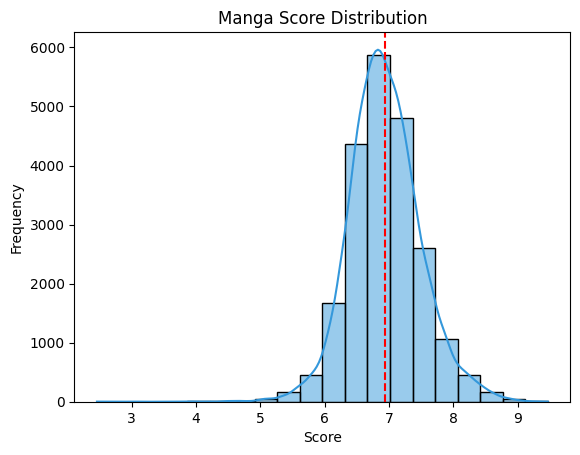

In [308]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['score'], kde=True, bins=20, color='#3498db') # Using a different shade of blue
plt.title('Manga Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.axvline(df['score'].mean(), color='red', linestyle='--', label=f'Mean: {df["score"].mean():.2f}')

**Top 10 Genres by Frequency**

In [309]:

df['genre_names'] = df['genres'].apply(
    # Lặp qua danh sách và lấy giá trị 'name', nếu 'genres' là một list
    lambda x: [genre.get('name') for genre in x] if isinstance(x, list) else []
)
all_genres_exploded = df.explode('genre_names')
genre_counts = all_genres_exploded['genre_names'].value_counts()
top_10_genres = genre_counts.head(10)
top_10_genres_df = top_10_genres.reset_index()
top_10_genres_df.columns = ['Genre', 'Frequency']
top_10_genres_df.to_csv('top_10_manga_genres.csv', index=False)
print(top_10_genres_df)

           Genre  Frequency
0        Romance       8267
1         Comedy       6632
2        Fantasy       5669
3         Action       4676
4          Drama       4606
5   Supernatural       3038
6      Adventure       2148
7  Slice of Life       2070
8          Ecchi       1731
9         Sci-Fi       1459


### **D. Data Preprocessing** <a name="distribution"></a>

**Multi-Label Encoding**

In [310]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

final_df = df.copy() 

nested_features = ['genres', 'demographics', 'themes', 'explicit_genres']

for feature in nested_features:
    # 1. Trích xuất tên (name) từ danh sách các từ điển
    list_of_names = final_df[feature].apply(
        lambda x: [item['name'] for item in x] if isinstance(x, list) else []
    )

    # 2. Áp dụng MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    encoded_features = mlb.fit_transform(list_of_names)
    
    # 3. Tạo DataFrame mới với các cột đã được mã hóa
    encoded_df = pd.DataFrame(
        encoded_features, 
        columns=[f'{feature}_{name}' for name in mlb.classes_],
        index=final_df.index
    )
    
    # 4. Nối DataFrame đã mã hóa vào DataFrame chính
    final_df = pd.concat([final_df, encoded_df], axis=1)
    
    # Xóa cột gốc
    final_df = final_df.drop(columns=[feature])

print(f"Add {len(final_df.columns) - df.shape[1]} new colunms from MultiLabelBinarizer.")

Add 73 new colunms from MultiLabelBinarizer.


**TF-IDF in Genres**

**Scaling**

In [311]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Các cột số học cần chuẩn hóa/chuyển đổi
numeric_cols = ['members', 'favorites', 'chapters', 'volumes']

# 1. Biến đổi Logarit cho các cột có độ lệch cao
# Log(1 + x) giúp giảm độ lệch và xử lý giá trị 0
final_df['members_log'] = np.log1p(final_df['members'])
final_df['favorites_log'] = np.log1p(final_df['favorites'])

# Xóa các cột gốc có độ lệch lớn (members, favorites)
final_df = final_df.drop(columns=['members', 'favorites'])

# Cập nhật danh sách cột cần Scale
scaling_cols = ['members_log', 'favorites_log', 'chapters', 'volumes']

# 2. Chuẩn hóa MinMaxScaler
scaler = MinMaxScaler()
final_df[scaling_cols] = scaler.fit_transform(final_df[scaling_cols])

print("Normalization complete for numeric columns")

print(final_df[scaling_cols].describe().transpose())

Normalization complete for numeric columns
                 count      mean       std  min       25%       50%       75%  \
members_log    21724.0  0.299019  0.144631  0.0  0.193758  0.274176  0.383631   
favorites_log  21724.0  0.194892  0.155464  0.0  0.092961  0.164656  0.278882   
chapters       21724.0  0.004485  0.011265  0.0  0.000154  0.001390  0.004786   
volumes        21724.0  0.017110  0.029917  0.0  0.000000  0.005000  0.020000   

               max  
members_log    1.0  
favorites_log  1.0  
chapters       1.0  
volumes        1.0  


## **3. Asking Meaning Questions** <a name="ask"></a>